In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# pd.set_option('display.max_colwidth', None)
# pd.set_option('display.max_row', 10)

In [3]:
df = pd.read_csv(r'C:\Users\Alex\Documents\testing\micole\research\Micole UX_CRO_SQL tabla school - exploration_Table (1).csv')

In [4]:
df['prefix'] = df['prefix'].replace(np.nan, '')
df['total'] = df['name'] + " " + df['prefix'] + " " + df['alias']

In [5]:
df['len'] = df['total'].str.len()#.std()

In [6]:
from sklearn.preprocessing import StandardScaler, normalize
scaler = StandardScaler(with_std=True,
                        with_mean=True)
df['scaled'] = scaler.fit_transform(np.array(df['len']).reshape(-1, 1))

In [16]:
df.len.describe()

count    27298.000000
mean        30.689135
std         12.663086
min         12.000000
25%         23.000000
50%         28.000000
75%         35.000000
max        139.000000
Name: len, dtype: float64

In [15]:
# counter = 1

for i in df.total.sample(50).to_list():
    print(f'{i}')
    # counter +=1

Gabriel Císcar IES  Instituto
C.E.I.P NUESTRA SEÑORA DE LA ENCARNACIÓN  Colegio
Terra De Turonio  Instituto
Escuela Municipal De Música De La Rambla  Instituto
De Aragón  Instituto
Navaliegos  Colegio
Lucano  Colegio
Joaquín Rodrigo  Instituto
Escuela Municipal De Música De Puente Genil  Instituto
L'alcudia CENTRE ENS. PROFESSIONALS DE MÚSICA  Instituto
Cesur Open Helicon  Instituto
Santíssima Trinitat  Colegio
Ciudad De Melilla  Instituto
Francisco Girona CEIP  Colegio
Yaiza  Instituto
Escuela De Musica De Cee  Instituto
Parc Estudi  Instituto
De Perdiguera  Escuela Infantil
CP los Campones CP Colegio
Los Colorines  Escuela Infantil
José Esquivel  Colegio
Formaduero  Instituto
L'areny  Colegio
Vital Alsar  Colegio
Rubió I Ors  Instituto
Hispanidad  Instituto
Josep Lluís Sert  Instituto
San Luis CENTRE PRIV. ED. INFANTIL  Escuela Infantil
Obrador De Músics De Marratxí  Instituto
Los Tiquis  Escuela Infantil
San Cristóbal Mártir II CENTRE PRIV. ED. INFANTIL  Escuela Infantil
Marpe-Ciuda

In [7]:
pd.set_option('display.max_rows', 30)
df[df['len'] <= 50]#.sort_values(by=['len'])

,name,prefix,alias,total,len,scaled
0,Municipal,,Instituto,Municipal Instituto,20,-0.844133
1,Escuela Municipal De Música,,Instituto,Escuela Municipal De Música Instituto,38,0.577347
2,Sagrada Familia,,Colegio,Sagrada Familia Colegio,24,-0.528249
3,San José,,Colegio,San José Colegio,17,-1.081047
4,Sagrado Corazón,,Colegio,Sagrado Corazón Colegio,24,-0.528249
...,...,...,...,...,...,...
27292,Andrés Torrejon,,Colegio,Andrés Torrejon Colegio,24,-0.528249
27293,Agora Madrid International School,,Colegio,Agora Madrid International School Colegio,42,0.893232
27295,Aben Hazam,,Colegio,Aben Hazam Colegio,19,-0.923104
27296,Liceo Villa Fontana,,Colegio,Liceo Villa Fontana Colegio,29,-0.133393


In [21]:
25068/27298

0.9183090336288373

In [8]:
count = []
for i in df['total']:
    for j in i.split():
        count.append(j)

In [9]:
df1 = pd.DataFrame(count, columns=['word'])
df1['len'] = df1['word'].apply(len)

In [10]:
df1.sort_values(by='len')

,word,len
9926,Y,1
37968,3,1
24724,Y,1
51738,I,1
12396,I,1
...,...,...
6715,Altas(ogíjares-gójar-dílar-otura),33
4959,Guadarromán(villarrubia-encinarejo),35
1676,Maquina-herramienta/makina-erreminta,36
6536,Poqueira(panpaneira-capileira-bubión),37


In [15]:
len(df1.len.unique())

36

(array([1.5110e+04, 7.9170e+03, 7.5140e+03, 1.0258e+04, 1.3900e+04,
        2.8052e+04, 1.3767e+04, 1.4458e+04, 2.5050e+03, 1.3740e+03,
        7.1600e+02, 5.5700e+02, 1.5000e+02, 1.1400e+02, 8.2000e+01,
        7.4000e+01, 7.5000e+01, 5.5000e+01, 3.8000e+01, 3.1000e+01,
        2.4000e+01, 1.9000e+01, 7.0000e+00, 1.0000e+01, 1.0000e+00,
        3.0000e+00, 3.0000e+00, 5.0000e+00, 2.0000e+00, 0.0000e+00,
        1.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00,
        2.0000e+00]),
 array([ 1.        ,  2.02777778,  3.05555556,  4.08333333,  5.11111111,
         6.13888889,  7.16666667,  8.19444444,  9.22222222, 10.25      ,
        11.27777778, 12.30555556, 13.33333333, 14.36111111, 15.38888889,
        16.41666667, 17.44444444, 18.47222222, 19.5       , 20.52777778,
        21.55555556, 22.58333333, 23.61111111, 24.63888889, 25.66666667,
        26.69444444, 27.72222222, 28.75      , 29.77777778, 30.80555556,
        31.83333333, 32.86111111, 33.88888889, 34.91666667, 35.9

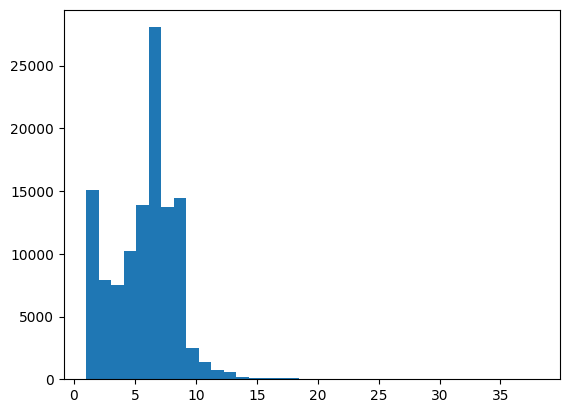

In [16]:
plt.hist(df1.len, bins=36)

In [55]:
df1[df1['len'] > 10].sort_values(by='len')

,word,len
77,Territorial,11
26618,Fedac-horta,11
86179,Marin-camos,11
26497,Fedac-prats,11
26493,Auxiliadora,11
...,...,...
6715,Altas(ogíjares-gójar-dílar-otura),33
4959,Guadarromán(villarrubia-encinarejo),35
1676,Maquina-herramienta/makina-erreminta,36
6536,Poqueira(panpaneira-capileira-bubión),37


In [51]:
df[df['len'] < 60].sort_values(by='len').tail(100)

,name,prefix,alias,total,len,scaled
2696,Ciutat Ducal,CENTRE ENS. PROFESSIONALS DE MÚSICA,Instituto,Ciutat Ducal CENTRE ENS. PROFESSIONALS DE MÚSICA Instituto,59,2.235741
5899,Salesianos Huesca (Colegio Salesiano San Bernardo),,Colegio,Salesianos Huesca (Colegio Salesiano San Bernardo) Colegio,59,2.235741
26174,Centro De Formación Y Capacitaciói Sopeña Madrid,,Instituto,Centro De Formación Y Capacitaciói Sopeña Madrid Instituto,59,2.235741
26181,Centro De Formación Profesional San Juan De Dios,,Instituto,Centro De Formación Profesional San Juan De Dios Instituto,59,2.235741
3091,Escuela Municipal De Música La Virgen Del Camino,,Instituto,Escuela Municipal De Música La Virgen Del Camino Instituto,59,2.235741
20408,Municipal El Castell Xicotet,EI 1er CICLE,Escuela Infantil,Municipal El Castell Xicotet EI 1er CICLE Escuela Infantil,59,2.235741
1005,Municipal De Cortes De Arenosos-s.vte.piedrahita,,Instituto,Municipal De Cortes De Arenosos-s.vte.piedrahita Instituto,59,2.235741
3040,Escuela Municipal De Música Y Danza De Algeciras,,Instituto,Escuela Municipal De Música Y Danza De Algeciras Instituto,59,2.235741
24898,La Serranía,ESCUELA PRIVADA DE MÚSICA LA SERRANIA,Instituto,La Serranía ESCUELA PRIVADA DE MÚSICA LA SERRANIA Instituto,59,2.235741
3955,Cap I Cua,CENTRE PRIV. ED. INF. 1er CICLE,Escuela Infantil,Cap I Cua CENTRE PRIV. ED. INF. 1er CICLE Escuela Infantil,59,2.235741


In [8]:
df.describe()

,len,scaled
count,27298.000000,2.729800e+04
mean,30.689135,-1.291044e-16
std,12.663086,1.000018e+00
min,12.000000,-1.475902e+00
25%,23.000000,-6.072197e-01
50%,28.000000,-2.123640e-01
75%,35.000000,3.404339e-01
max,139.000000,8.553433e+00


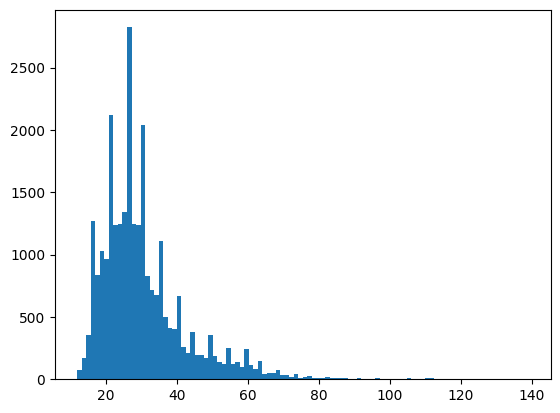

In [51]:
plt.hist(df['len'], bins=100)
plt.show()